# Chapter 9: more numpy
A few more topics in somewhat random order

## 9.8 Reading and writing files
Reading data from *text* files is relatively straightforward. We'll see later how to handle some other types of files.


In [7]:
import numpy as np
A2 = np.array([[1, 2, 3], [4, 5, 6]])
np.savetxt('testfile.txt', A2)
np.savetxt('testfile.csv', A2, delimiter=',', header='col1, col2, col3')

# use the help for more options and their meaning 
# help(np.savetxt) 

Conversely, we can import data from text files: 

In [12]:
grades = np.loadtxt('grades.csv', skiprows = (1), usecols = (9), delimiter = ',')
print(grades)

[ 91.  88.  87.  84.  81.  95.  92.  89.  91.  90.  86.  85.  91.  89.
  85.  87.  82.  77.  85.  90.  92.  95.  85.  90.  97.  85.  85.  89.
  89.  87.  86.  85.  76.  89.  91.  82.  85.  85.  89.  94.  92.  82.
  88.  92.  82.  88.  84.  86.  77.  81.  82.  81.  85.  85.  80.  82.
  87.  93.  80.  75.  92.  75.  83.  88.  92.  87.  86.  93.  84.  81.
  89.  92.  89.  88.  95.  85.  91.  91.  84.  85.  83.  82.  83.  82.
  88.  85.  93.  91.  90.  76.  88. 100.  89.  79.  86.  76.  87.  91.
  86.  78.  83.  76.  92.  87.  90.  82.  85.  85.  79.  90.  88.  80.
  86.  84.  87.  88.  82.  82.  93.  83.  90.  88.  88.  77.  89.  89.
  90.  86.  91.  99.  82.  82.  84.  90.  84.  83.  78.  77.  84.  83.
  79.  91.  87.  84.  92.  85.  82.  84.  87.  85.  89.  90.  85.  87.
  93.  84.  85.  85.  84.  95.  85.  84.  83.  80.  78.  90.  93.  82.
  80.  90.  88.  94.  87.  81.  81.  89.  92.  84.  84.  90.  88.  90.
  86.  84.  89.  89.  94.  83.  94.  92.  92.  87.  83.  88.  90.  88.
  80. 

## 9.9 Random numbers
`np.random` gives access to several types of random number generators. Some of the most relevant are
* `np.random.uniform`: uniformly distributed numbers
* `np.random.normal`: a 'normal' distribute ("bell curve")

In [18]:
unif = np.random.uniform(low = -10, high = 10, size = (3,4))
print(unif)


mean = 0
stddev = 5
normal = np.random.normal(0, 5, size=(3,4))
print(normal)

[[ 2.91195814 -7.56489722  7.70188888  8.37544684]
 [ 4.50972142 -3.86094339  1.84597822  4.31503057]
 [-7.04960226 -1.62485657  0.05129117 -0.22662215]]
[[-6.04498968  6.48530489 -1.14331748 -0.08851567]
 [ 7.25844892 -2.46685098  6.49400757 -1.46057727]
 [-6.22223694  8.29255492 -1.60066575  2.27769083]]


visualizing the difference:

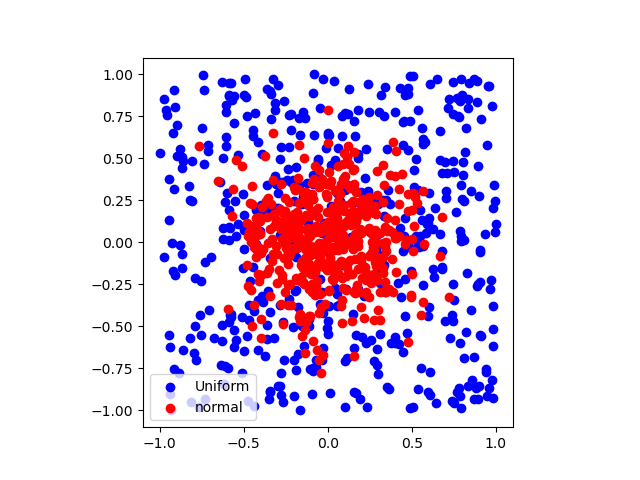

In [29]:
%matplotlib widget
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
n = 501
X = np.random.uniform(low= -1, high = 1, size =(n,))
Y = np.random.uniform(low= -1, high = 1, size =(n,))
ax.scatter(X,Y, color='b', label = 'Uniform')
X = np.random.normal(loc= 0, scale = 0.25, size =(n,))
Y = np.random.normal(loc= 0, scale = 0.25, size =(n,))
ax.scatter(X,Y, color='r', label = 'normal')
ax.set_aspect('equal', 'box')
ax.legend()

### Application: A very inefficient away to compute $\pi$.
The idea of the Monte Carlo method to compute $\pi$ is to estimate the probability that a point with uniform random coordinates in (-1,1) is in the circle of diameter 1 is proportional to the ratio of the area of the circle over the square, $\pi/4$

In [41]:
npoints = 1000
for j in range(10):
    count = 0
    for i in range(npoints):
        x = np.random.uniform(low = -1, high = 1)
        y = np.random.uniform(low = -1, high = 1)
        if x**2 + y**2 < 1:
            count += 1
    piApprox = 4*count / npoints
    print(f"After {npoints} trials, pi ~ {piApprox} (error {100*abs((np.pi-piApprox)/np.pi):.2f}%)")

After 1000 trials, pi ~ 3.112 (error 0.94%)
After 1000 trials, pi ~ 3.108 (error 1.07%)
After 1000 trials, pi ~ 3.172 (error 0.97%)
After 1000 trials, pi ~ 3.172 (error 0.97%)
After 1000 trials, pi ~ 3.12 (error 0.69%)
After 1000 trials, pi ~ 3.18 (error 1.22%)
After 1000 trials, pi ~ 3.184 (error 1.35%)
After 1000 trials, pi ~ 3.1 (error 1.32%)
After 1000 trials, pi ~ 3.088 (error 1.71%)
After 1000 trials, pi ~ 3.072 (error 2.22%)
